In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Introduction

In [ ]:
# Import Libraries

import numpy as np # linear algebra
import pandas as pd # for data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns # for data visualization
import matplotlib.pyplot as plt # for data visulaization
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
!pip install catboost
import catboost
import xgboost
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.6 MB/s eta 0:00:00


In [ ]:
import warnings

# Ignore all warnings
warnings.filterwarnings("ignore")

# Load datasets

In [ ]:
# Load Competiton Datasets and drop breast_cancer_diagnosis_code
df = pd.read_csv("/content/drive/MyDrive/2025_DataMining/WiDS/training.csv")
tdf = pd.read_csv("/content/drive/MyDrive/2025_DataMining/WiDS/test.csv")
ss = pd.read_csv("/content/drive/MyDrive/2025_DataMining/WiDS/sample_submission.csv")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/2025_DataMining/WiDS/training.csv'

In [ ]:
df.info()

In [ ]:
target = "DiagPeriodL90D"

# Count the occurrences of each class
class_counts = df[target].value_counts()

# Plot the class distribution
plt.figure(figsize=(8, 6))
class_counts.plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('Classes')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Feature Engineering

### NO2, PM25, commute_time - Missing Value

- patient_zip2 기반의 평균값으로 대체

In [ ]:
# patient_zip2 파생 변수 생성
df['patient_zip2'] = df['patient_zip3'].astype(str).str[:2]
tdf['patient_zip2'] = tdf['patient_zip3'].astype(str).str[:2]


# 전처리할 컬럼 리스트
target_cols = ['N02', 'PM25', 'commute_time']

# df, tdf 각각에 대해 그룹별 평균으로 결측치 채우기
for dataset in [df, tdf]:
    for col in target_cols:
        dataset[col] = dataset.groupby('patient_zip2')[col].transform(lambda x: x.fillna(x.mean()))

In [ ]:
# 각 컬럼의 결측치 개수 출력
for col in ['N02', 'PM25', 'commute_time']:
    missing_count = df[col].isnull().sum()
    print(f"{col} 결측치 개수: {missing_count}")

### NO2 x PM25 x commute_time + MinMax Scaling

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# 스케일링 대상 컬럼
cols = ['N02', 'PM25', 'commute_time']

# MinMax 스케일러 정의
scaler = MinMaxScaler()

# df 정규화
df_scaled = pd.DataFrame(scaler.fit_transform(df[cols]), columns=cols, index=df.index)
df['N02xPM25xcommute_time'] = df_scaled['N02'] * df_scaled['PM25'] * df_scaled['commute_time']

# tdf 정규화 (df 기준으로 transform)
tdf_scaled = pd.DataFrame(scaler.transform(tdf[cols]), columns=cols, index=tdf.index)
tdf['N02xPM25xcommute_time'] = tdf_scaled['N02'] * tdf_scaled['PM25'] * tdf_scaled['commute_time']

### train + test

In [ ]:
# define target variable and categorical features
cat_cols = list(tdf.columns[tdf.dtypes=="object"])
cols = [col for col in tdf.columns if col not in ["patient_id"]]
tdf[target] = np.nan

# concatenate train and test set
df = pd.concat([df,tdf[df.columns]],axis=0)

### clust + is_female

In [ ]:
df["clust"]=(df.metastatic_cancer_diagnosis_code.str.len()==4).astype("int")
df["is_female"] = df.breast_cancer_diagnosis_desc.str.contains("female").astype("int")
df["is_female"].value_counts()

### meta_code4

In [ ]:
# meta 칼럼에서 5자리 값을 4자리로 변환
df['meta_code4'] = df['metastatic_cancer_diagnosis_code'].astype(str).apply(lambda x: x[:4] if len(x) >= 5 else x)

# 결과 확인
print(df['meta_code4'].nunique())
print(df['meta_code4'].value_counts())

#metastatic_cancer_diagnosis_code 드랍하기
df = df.drop(columns=['metastatic_cancer_diagnosis_code'])

### ICD_version

In [ ]:
# ICD_version 파생변수 생성 (ICD-10이면 0, ICD-9이면 1)

df['ICD_version'] = np.where(df['breast_cancer_diagnosis_code'].astype(str).str.startswith('C'), 'ICD-10', 'ICD-9')
print(df['ICD_version'].value_counts())

### Breast Cancer - Code & Desc Mapping

In [ ]:
# ## ICD9 -> ICD10 매핑
# ## breast_cancer_diagnosis_desc
# ## breast_cancer_diagnosis_code

# # 1. ICD9 -> ICD10 코드(code) 매핑
# icd9_to_icd10 = {
#     '1749': 'C50919', '1744': 'C50419',
#     '1748': 'C50819', '1742': 'C50219',
#     '1741': 'C50119', '1745': 'C50519',
#     '1743': 'C50319', '1746': 'C50619',
#     '19881': 'C7981', '1759': 'C50929'
# }

# # 2. ICD-10 ➝ 진단명(desc) 매핑
# icd10_to_desc = {
#     "C50919": "Malignant neoplasm of unsp site of unspecified female breast",
#     "C50419": "Malig neoplasm of upper-outer quadrant of unsp female breast",
#     "C50819": "Malignant neoplasm of ovrlp sites of unsp female breast",
#     "C50219": "Malig neoplasm of upper-inner quadrant of unsp female breast",
#     "C50119": "Malignant neoplasm of central portion of unsp female breast",
#     "C50519": "Malig neoplasm of lower-outer quadrant of unsp female breast",
#     "C50319": "Malig neoplasm of lower-inner quadrant of unsp female breast",
#     "C50619": "Malignant neoplasm of axillary tail of unsp female breast",
#     "C50929": "Malignant neoplasm of unsp site of unspecified male breast",
#     "C7981": "Secondary malignant neoplasm of breast"
# }


# # 1-(1). ICD9 -> ICD10 코드(code) 매핑 적용
# df['breast_cancer_diagnosis_code_mapped'] = df['breast_cancer_diagnosis_code'].astype(str).replace(icd9_to_icd10)

# # 2-(2). ICD-10 ➝ 진단명(desc) 매핑 적용
# df['breast_cancer_diagnosis_desc_mapped'] = df['breast_cancer_diagnosis_code_mapped'].map(icd10_to_desc).fillna(df['breast_cancer_diagnosis_desc'])

## tumor_site

In [ ]:
# # desc를 소문자로 변환하여 새로운 컬럼 생성
# df['desc_lower'] = df['breast_cancer_diagnosis_desc_mapped'].str.lower()

# # 위치 기반 파생 변수 생성
# df['tumor_site'] = np.select(
#     [
#         df['desc_lower'].str.contains('inner'),
#         df['desc_lower'].str.contains('outer') | df['desc_lower'].str.contains('axillary tail'),
#         df['desc_lower'].str.contains('central portion') | df['desc_lower'].str.contains('nipple') | df['desc_lower'].str.contains('areola'),
#         df['desc_lower'].str.contains('overlapping') | df['desc_lower'].str.contains('ovrlp'),
#         df['desc_lower'].str.contains('unspecified') | df['desc_lower'].str.contains('unsp')
#     ],
#     [
#         'Inner',
#         'Outer',
#         'Central',
#         'Overlapping',
#         'Unspecified'
#     ],
#     default='Unspecified'
# )
# df['tumor_site'].value_counts()

## patient_race - Missing Value

In [ ]:
## 해야해

## Columns Drop (zip3 Groupby & others

In [ ]:
len(df.columns)

In [ ]:
# Drop some features

# List of columns to iterate over
columns_to_iterate = [col for col in df.columns if col not in ["patient_zip3", "N02xPM25xcommute_time"]]

# Iterate over each column
for col in columns_to_iterate:
    # Your code to operate on each column goes here
    df["check"]=df.groupby(["patient_zip3","N02xPM25xcommute_time"])[col].transform("nunique")
    if df["check"].max()==1:
        print("dropped ",col)
        df=df.drop(col,axis=1)
        # tdf=tdf.drop(col,axis=1)
df=df.drop("check",axis=1)

In [ ]:
# - Region
# - patient_zip3
# - desc_lower
# - breast_cancer_diagnosis_code
# - breast_cancer_diagnosis_desc
# - breast_cancer_diagnosis_code_mapped
# - breast_cancer_diagnosis_desc_mapped

df = df.drop(columns=[
    'Region', 'patient_zip3',
    # 'desc_lower',
    # 'breast_cancer_diagnosis_code_mapped',
    # 'breast_cancer_diagnosis_desc_mapped',
    # 'breast_cancer_diagnosis_desc',
    'breast_cancer_diagnosis_code',
])

In [ ]:
df.columns.to_list()

In [ ]:
len(df.columns)

## One-Hot Encoding

In [ ]:
# One-Hot Encoding
categorical_cols = [col for col in df.columns
                    if df[col].dtype == 'object']

In [ ]:
categorical_cols

In [ ]:
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype="int")

In [ ]:
# do label encoding for categorical columns
le = LabelEncoder()
for col in cat_cols:
    try:
        df[col]=le.fit_transform(df[col]).astype("int")
        print(col)
    except:
        continue

In [ ]:
tdf = df[df[target].isna()]
df = df[df[target].notna()]
len(df), len(tdf)
# 분리하는 코드

# Data Cleaning

Zip code level metadata were dropped except product of N02,PM25 & Ozone

Data set contained missing values which we left unhandled


In [ ]:
len(df.columns)

In [ ]:
for col in df.columns:
    print(col)

NameError: name 'df' is not defined

# Modeling

In [ ]:
# ▶ CatBoost
modela = CatBoostClassifier(
    iterations = 500,
    silent = True,
    learning_rate = 0.05,
    depth = 10,
    eval_metric = 'AUC',
    random_seed = 42
)

# ▶ RandomForest
modelb = RandomForestClassifier(
    n_estimators = 200,
    max_depth = None,
    min_samples_split = 2,
    random_state = 42,
    n_jobs = -1
)

# ▶ XGBoost
modelc = XGBClassifier(
    learning_rate = 0.1,
    max_depth = 6,
    n_estimators = 100,
    subsample = 0.9
)

In [ ]:
# finalize features for training
drop_cols = ["patient_id", target, "patient_zip3", "patient_state"]
cols = list(set(df.columns) - set(drop_cols))

NameError: name 'target' is not defined

In [ ]:
print("모델 학습에 사용된 feature 개수:", len(cols))
print("사용된 feature 리스트:")
for col in cols:
    print(col)

모델 학습에 사용된 feature 개수: 145
사용된 feature 리스트:
patient_age
meta_code4_C774
patient_state_IL
patient_state_MS
patient_state_WY
breast_cancer_diagnosis_desc_Malig neoplasm of lower-outer quadrant of unsp female breast
payer_type_MEDICAID
breast_cancer_diagnosis_desc_Malig neoplasm of upper-inner quadrant of left female breast
patient_state_OK
Division_New England
meta_code4_C785
patient_state_KS
meta_code4_C799
meta_code4_C779
patient_state_DC
N02xPM25xcommute_time
patient_state_NV
breast_cancer_diagnosis_desc_Malignant neoplasm of other specified sites of female breast
breast_cancer_diagnosis_desc_Malig neoplm of lower-outer quadrant of right female breast
breast_cancer_diagnosis_desc_Malignant neoplasm of other and unspecified sites of male breast
meta_code4_C773
patient_state_ID
clust
patient_state_TN
patient_state_NJ
breast_cancer_diagnosis_desc_Malignant neoplasm of central portion of breast, female
patient_state_CA
meta_code4_C797
Division_Middle Atlantic
breast_cancer_diagnosis_desc_

In [ ]:
# Define the number of folds
num_folds = 10
from sklearn.model_selection import StratifiedKFold
kf = StratifiedKFold(n_splits = num_folds, shuffle = True, random_state = 42)

In [ ]:
# use stacking method, define meta model
from sklearn.linear_model import LogisticRegression
meta_model = LogisticRegression()
meta_features = ['pred1','pred2','pred3']

In [ ]:
# Initialize empty dataframe to store predictions from all folds
predictions_from_folds = pd.DataFrame()
# Iterate over folds
for fold, (train_index, val_index) in enumerate(kf.split(df, df[target])):
    dfx, efx = df.iloc[train_index], df.iloc[val_index]
    # train and make predictions on train set
    efx["pred1"] = modela.fit(dfx[cols].values, dfx[target]).predict_proba(efx[cols].values)[:,1]
    efx["pred2"] = modelb.fit(dfx[cols].values, dfx[target]).predict_proba(efx[cols].values)[:,1]
    efx["pred3"] = modelc.fit(dfx[cols].values, dfx[target]).predict_proba(efx[cols].values)[:,1]
    # make predictions on test set
    tdf["pred1"] = modela.predict_proba(tdf[cols].values)[:,1]
    tdf["pred2"] = modelb.predict_proba(tdf[cols].values)[:,1]
    tdf["pred3"] = modelc.predict_proba(tdf[cols].values)[:,1]
    # train meta-models and make final predictions
    tdf["pred"] = meta_model.fit(efx[meta_features], efx[target]).predict_proba(tdf[meta_features])[:, 1]
    predictions_from_folds = pd.concat([predictions_from_folds,tdf],axis=0)

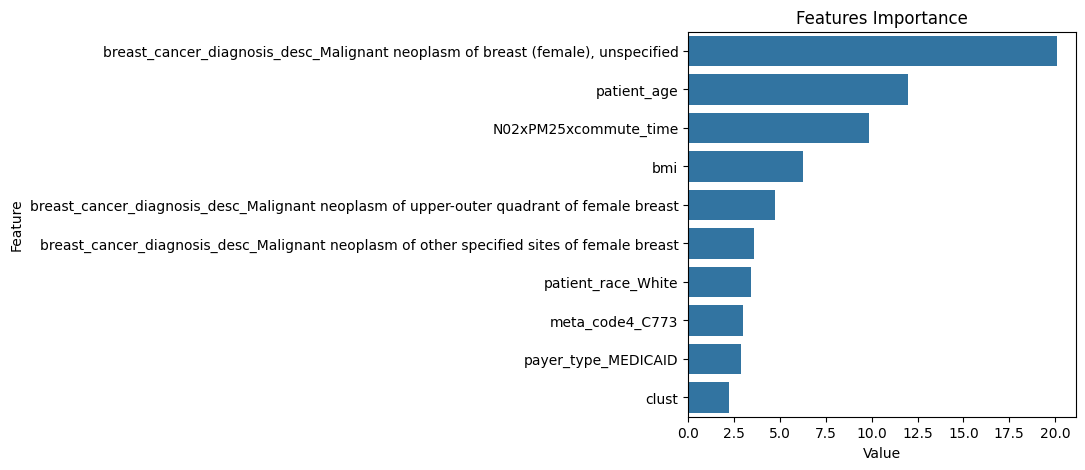

In [ ]:
# feature importance

feature_imp = pd.DataFrame(sorted(zip(modela.feature_importances_,cols)), columns = ['Value', 'Feature'])
feature_imp = feature_imp.sort_values("Value", ascending = False)
feature_imp = feature_imp.head(10)
feature_imp["Feature"] = feature_imp["Feature"]
plt.figure(figsize = (5, 5))
sns.barplot(x = "Value", y = "Feature", data = feature_imp.sort_values(by = "Value", ascending = False))
plt.title('Features Importance')
plt.tight_layout()
plt.savefig('cb_importances.png')
plt.show()

# Submission

In [ ]:
# blend predictions from all folds
final_predictions = predictions_from_folds.groupby("patient_id").mean().reset_index()
final_predictions[target] = final_predictions["pred"].values
final_predictions[ss.columns].to_csv("final_predictions.csv", index = None)

In [ ]:
from google.colab import files
files.download("final_predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>